In [38]:
import numpy as np
import pandas as pd

In [39]:
data_frame = pd.read_csv('Seattle500.csv')
data_frame

,id,year,zip_code,city,state,climate,building_class,facility_type,floor_area,year_built,energy_star_rating,leed_score,electric_eui,fuel_eui,site_eui,source_eui,ghg_emissions_int
0,1,2015,98101,Seattle,WA,4C Mixed - Marine (Salem-OR),Commercial,Lodging - Hotel,88434,1927,65.0,NaN,41.698040,37.262684,78.960724,173.488862,6.626953
1,1,2016,98101,Seattle,WA,4C Mixed - Marine (Salem-OR),Commercial,Lodging - Hotel,88434,1927,60.0,NaN,44.501527,36.996582,81.498108,181.971440,6.142425
2,1,2017,98101,Seattle,WA,4C Mixed - Marine (Salem-OR),Commercial,Lodging - Hotel,88434,1927,63.0,NaN,44.670624,38.577274,83.247898,184.372457,6.223984
3,1,2018,98101,Seattle,WA,4C Mixed - Marine (Salem-OR),Commercial,Lodging - Hotel,88434,1927,60.0,NaN,44.191296,39.580726,83.772022,183.866097,6.196975
4,1,2019,98101,Seattle,WA,4C Mixed - Marine (Salem-OR),Commercial,Lodging - Hotel,88434,1927,62.0,NaN,43.750334,39.306677,83.057011,182.306968,6.597195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,19454,2018,98115,Seattle,WA,4C Mixed - Marine (Salem-OR),Residential,2-4 Unit Building,29914,1990,89.0,NaN,30.743744,0.000000,30.743744,96.535356,2.630209
495,19454,2019,98115,Seattle,WA,4C Mixed - Marine (Salem-OR),Residential,2-4 Unit Building,29914,1990,91.0,NaN,30.095421,0.000000,30.095421,94.499623,2.878703
496,19454,2020,98115,Seattle,WA,4C Mixed - Marine (Salem-OR),Residential,2-4 Unit Building,29914,1990,87.0,NaN,31.113357,0.000000,31.113357,97.695940,2.497289
497,19454,2021,98115,Seattle,WA,4C Mixed - Marine (Salem-OR),Residential,2-4 Unit Building,29914,1990,86.0,NaN,32.809653,0.000000,32.809653,103.022309,2.784948


In [40]:
df_eui = pd.DataFrame(data_frame[['year_built', 'source_eui']])
df_eui

,year_built,source_eui
0,1927,173.488862
1,1927,181.971440
2,1927,184.372457
3,1927,183.866097
4,1927,182.306968
...,...,...
494,1990,96.535356
495,1990,94.499623
496,1990,97.695940
497,1990,103.022309


<Axes: title={'center': 'Source EUI'}, xlabel='Year Built', ylabel='BTU/sq ft/year'>

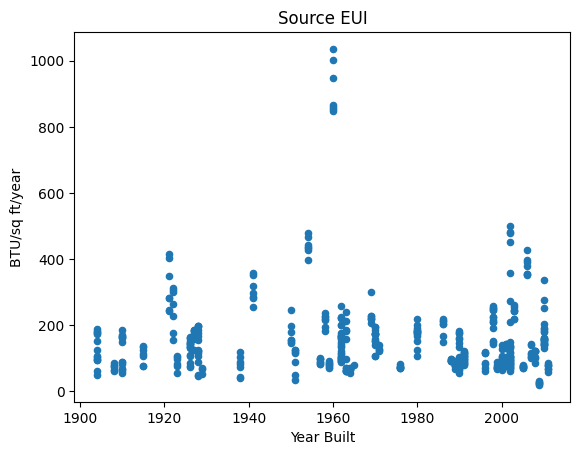

In [41]:
df_eui.plot(kind='scatter', title='Source EUI', \
    xlabel='Year Built', ylabel='BTU/sq ft/year', x='year_built', y='source_eui')

In [42]:
df_ave = df_eui.groupby('year_built', as_index=False)['source_eui'].median()
df_ave.set_index('year_built', inplace=True)



<Axes: title={'center': 'Median Source EUI'}, xlabel='Year Built', ylabel='BTU/sq ft/year'>

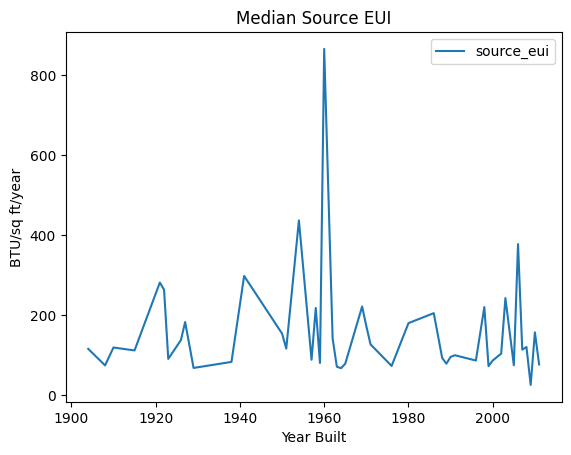

In [43]:
df_ave.plot(kind='line', title='Median Source EUI',  xlabel='Year Built', ylabel='BTU/sq ft/year')


In [44]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
year_array = df_ave.index.values.reshape(-1, 1)
regressor.fit(year_array, df_ave['source_eui'].values)
y_fit = regressor.predict(year_array)
df_fit = df_ave.assign(fit = y_fit)
df_fit

,source_eui,fit
year_built,,
1904,115.002332,176.317265
1908,73.476758,174.947958
1910,118.299030,174.263305
1915,110.953321,172.551672
1921,280.774947,170.497712
1922,262.945795,170.155385
1923,89.795225,169.813059
1926,136.858434,168.786079
1927,181.971440,168.443752


<Axes: title={'center': 'Median Source EUI'}, xlabel='Year Built', ylabel='BTU/sq ft/year'>

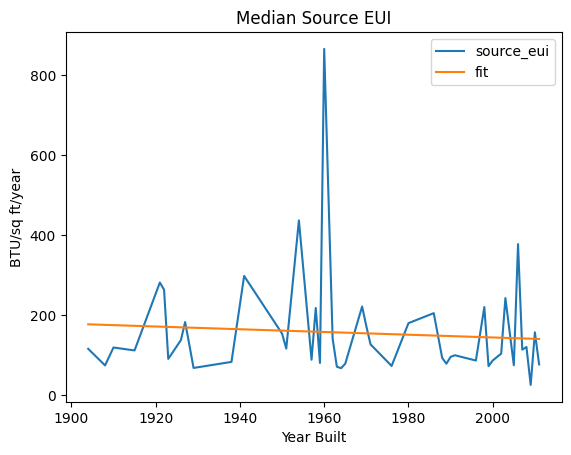

In [45]:
df_fit.plot(kind='line', title='Median Source EUI',  xlabel='Year Built', ylabel='BTU/sq ft/year')


In [46]:
more_years = np.array([2025, 2030, 2035]).reshape(-1, 1)
regressor.predict(more_years)


array([134.89573996, 133.1841067 , 131.47247343])

In [47]:
df_floor = pd.DataFrame(data_frame[['floor_area', 'source_eui']])


<Axes: title={'center': 'Source EUI'}, xlabel='Floor Area', ylabel='BTU/sq ft/year'>

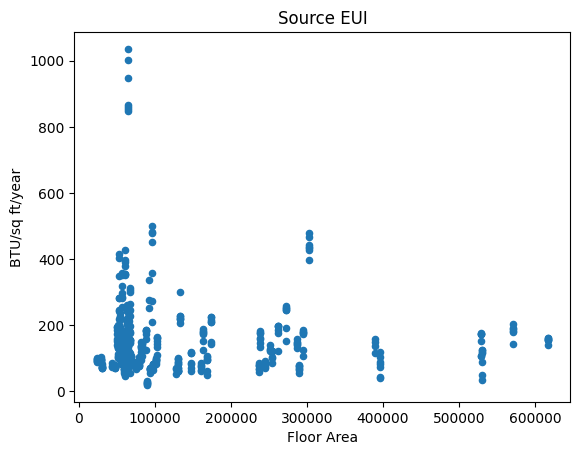

In [48]:
df_floor.plot(kind='scatter', title='Source EUI', \
    xlabel='Floor Area', ylabel='BTU/sq ft/year', x='floor_area', y='source_eui')

In [49]:
df_avg = df_floor.groupby('floor_area', as_index=False)['source_eui'].median()
df_avg.set_index('floor_area', inplace=True)

<Axes: title={'center': 'Median Source EUI'}, xlabel='Floor Area', ylabel='BTU/sq ft/year'>

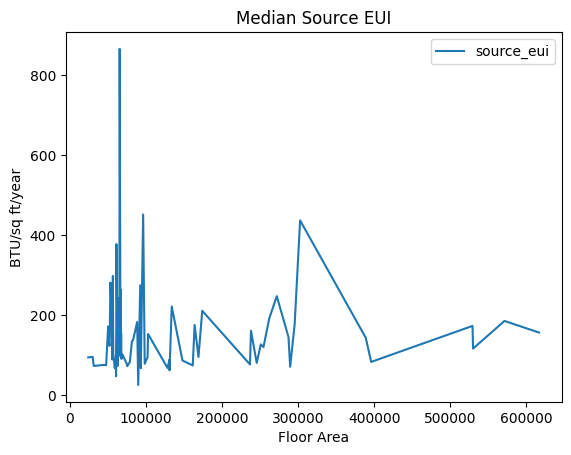

In [50]:
df_avg.plot(kind='line', title='Median Source EUI',  xlabel='Floor Area', ylabel='BTU/sq ft/year')


In [51]:
regressor2 = LinearRegression()
floor_array = df_avg.index.values.reshape(-1, 1)
regressor2.fit(floor_array, df_avg['source_eui'].values)
y_fit2 = regressor2.predict(floor_array)
df_fit2 = df_avg.assign(fit = y_fit2)

In [52]:
more_area = np.array([2025, 2030, 2035]).reshape(-1, 1)
regressor2.predict(more_area)

array([151.5301214 , 151.53016825, 151.5302151 ])

<Axes: title={'center': 'Median Source EUI'}, xlabel='Floor Area', ylabel='BTU/sq ft/year'>

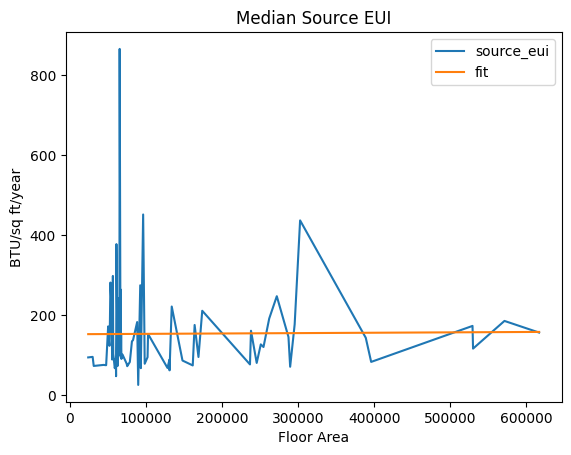

In [53]:
df_fit2.plot(kind='line', title='Median Source EUI', xlabel='Floor Area', ylabel='BTU/sq ft/year')

In [56]:
df_floor_clean = df_floor.dropna()
regressor3 = LinearRegression()
floor_array2 = df_floor_clean['floor_area'].values.reshape(-1, 1)   
regressor3.fit(floor_array2, df_floor_clean['source_eui'].values)   
y_fit3 = regressor3.predict(floor_array2)
df_fit3 = df_floor_clean.assign(fit=y_fit3)
df_fit3

,floor_area,source_eui,fit
0,88434,173.488862,156.321474
1,88434,181.971440,156.321474
2,88434,184.372457,156.321474
3,88434,183.866097,156.321474
4,88434,182.306968,156.321474
...,...,...,...
494,29914,96.535356,158.085017
495,29914,94.499623,158.085017
496,29914,97.695940,158.085017
497,29914,103.022309,158.085017
